# Project 4
Author: Daniel Ulstad Kaarvaag, Marzena Switon and Patrick Roarson Teigen 

### Abstract
## INTRODUCTION:

 In this project we explores the application of unsupervised machine learning techniques to analyze and manipulate pictures taken of the milky way galaxy withe the "skymap" function. Altering the images into numpy arrays lets us utilize the K-means clustering algorithms. THe main learning is to identify and categorize different star/brightness populations based on their colors and brightness patterns.

 This project will provide key learnings on manipulating pictures, but from a wider point of view it also shows us how to see that algorithms can reveal patterns that might not be immediately obvious to the human eye. Unlike supervised learning, which requires known training data, unsupervised methods like K-means can discover natural groupings in data automaticly.

Through a series of progressive tasks, we will:
- Generate multiple views of the milky way from different centers and zoom levels
- Process images using grayscale conversion and brightness filtering
- Apply K-means clustering to groups with similar pixels
- Visualize clustering results

# Task 0 
Installing the python library and iporting necessary imports

In [ ]:
#   pip install mw_plot 

     ---------------------------------------- 0.0/38.4 MB ? eta -:--:--
     ------ --------------------------------- 6.0/38.4 MB 33.5 MB/s eta 0:00:01
     ----------------- --------------------- 16.8/38.4 MB 50.4 MB/s eta 0:00:01
     ------------------ -------------------- 18.1/38.4 MB 31.7 MB/s eta 0:00:01
     -------------------------------- ------ 31.7/38.4 MB 40.3 MB/s eta 0:00:01
     --------------------------------------- 38.4/38.4 MB 41.4 MB/s eta 0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/6.3 MB ? eta -:--:--
   ------------- -------------------------- 2.1/6.3 MB 14.7 MB/s eta 0:00:01
   -------------------------- ------------- 4.2/6.3 

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from ebola_loader import EbolaDataLoader
from linReg import LinearRegressionFit
from ImprovedLinReg import PolynomialRegressionFit
from NN_SupervisedLearning import NNEpidemicPrediction
from funct import chocolate_milkyway, plt2rgbarr
from astropy import units as u
from mw_plot import MWSkyMap
from sklearn.linear_model import LinearRegression
from matplotlib.colors import ListedColormap
from sklearn.cluster import KMeans
from sklearn.cluster import KMeans 
from PIL import Image  
from matplotlib.colors import rgb_to_hsv
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Topic 1: Unsupervised learning
## Clustrering the Milky Way

### Task 1: Installing the git package and reproducing the image of the milky way

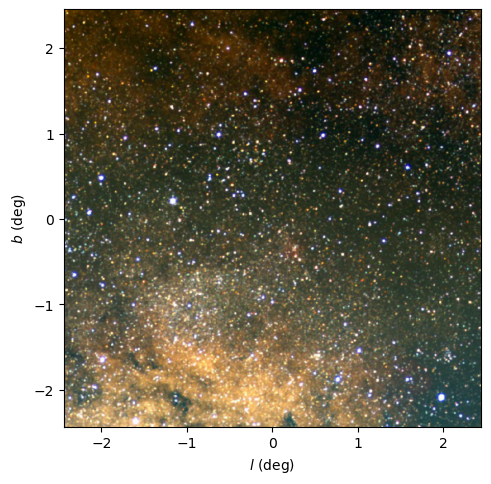

In [2]:
### Had to use coordinates becaus something is wrong with my installment, it wont retreive the strings
mw1 = MWSkyMap(
    center = (10.68, 41.27) * u.arcsec,               
    radius=(8800, 8800) * u.arcsec,
    background="Mellinger color optical survey",
)

fig, ax = plt.subplots(figsize=(5, 5))

mw1.transform(ax)

mw1.savefig('galaxy.png')
plt.show()

### Task 2: Generating a few visualization of the milky way via MWSkyMap 

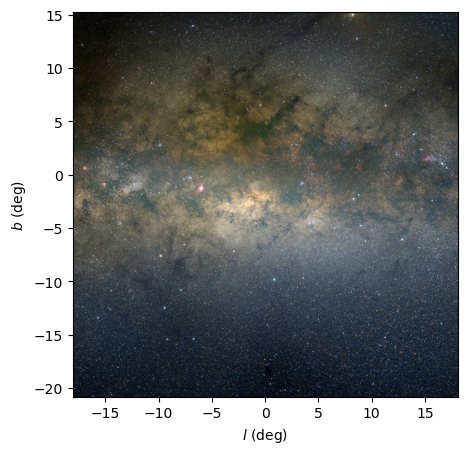

Saved: view1.png


In [3]:
chocolate_milkyway(
    center=(5, -10000),
    radius=(65000, 65000),       ### Call function 1
    title="",                    
    filename="view1.png"
)

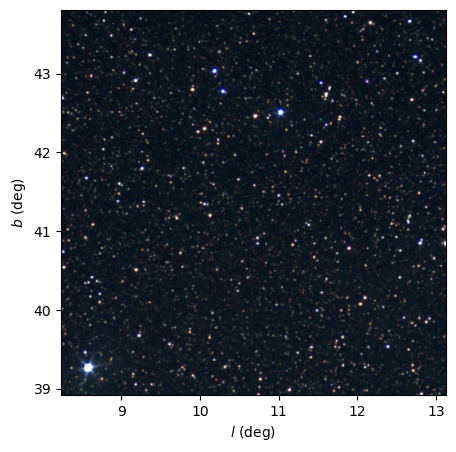

Saved: view2.png


In [4]:
chocolate_milkyway(
    center=(38448, 148920),
    radius=(8800, 8800),        ### Call function 2
    title="",                   ### Found online that this was the coordinates for the andromeda
    filename="view2.png"
)

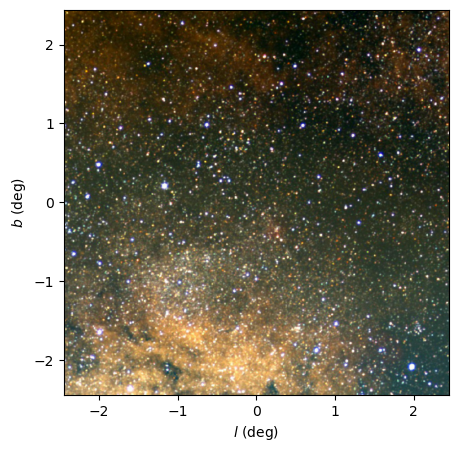

Saved: view3.png


In [5]:
chocolate_milkyway(
    center=(0, 0),
    radius=(8800, 8800),        ### Call function 3
    title="",
    filename="view3.png"
)

### Task 3: Converting image into a rgb np.array

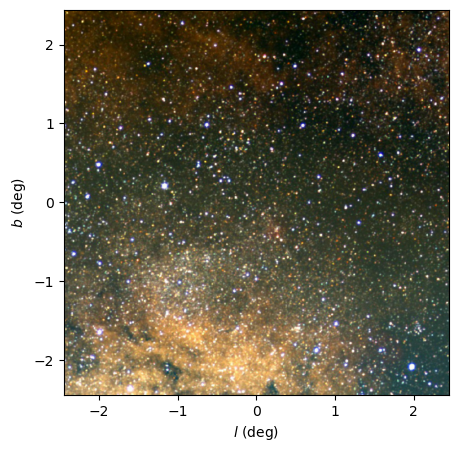

Saved: view1.png
Image shape: (500, 500, 3)
Sample pixel: [0 0 0]


In [6]:
chocolate_milkyway(
    center=(0, 0),
    radius=(8800, 8800),     
    title="",                    
    filename="view1.png"
)

# Convert to RGB array
img_array = plt2rgbarr(fig)

# Check the result
print(f"Image shape: {img_array.shape}")  
print(f"Sample pixel: {img_array[0, 0]}")  # Shows [R, G, B] values

plt.show()

### Task 4: Encoding 
From task 3 I got an image represented as a numpy array with dimensions (360, 360, 3), meaning 360 rows, 360 columns, and 3 color channels (RGB).

Step 1 Print the image shape to confirm dimensions

Step 2: Convert RGB image to grayscale using formula from attached file. The formula i think shows how the human eye see brightness.

Step 3: Filter bright pixels with an adjustable threshold (now set at 150). Find all pixel positions (x, y) above the brightness limit (stars).

Step 4: For each bright pixel position, get the original RGB colors from the image. This gives us a list of color values that we can group with K-means.

In [7]:
#1.
print(f"original image shape:{img_array.shape} " )  # Meaning: 360 rows × 360 columns × 3 colors (RGB)

#2.
grey = np.sum(img_array[: , : , :] * np.array([0.299, 0.587, 0.114]), axis=2)  # From RGB to grey

#3. 
bright_limit = 150
x, y = [], []
for ig, g in enumerate(grey):                  # from attached file-- A grey encoding
    for ij, j in enumerate(g): 
        if j > bright_limit:
            x.append(ig)
            y.append(ij)     
#4
intensity=[]             # creates a list to store different brightness in pixels 
for xi, yi in zip(x, y):            # Loops through each pair of positions from x and y lists, zip(x, y) combines them
    intensity.append(img_array[xi, yi])       # Get the RGB color at position xi,yi from the original image, and add rgb values to intensity list
intensity = np.array(intensity)            # Converts the list into a numpy array for K-means

original image shape:(500, 500, 3) 


### Task 5: Clustering the data

Intensity array shape: (20465, 3)
Clustered 20465 pixels into 3 groups

Cluster distribution:
  Cluster 0: 3608 pixels (17.6%)
  Cluster 1: 10862 pixels (53.1%)
  Cluster 2: 5995 pixels (29.3%)

Cluster centers (RGB):
  Cluster 0: RGB(218, 212, 204)
  Cluster 1: RGB(192, 158, 110)
  Cluster 2: RGB(226, 186, 125)


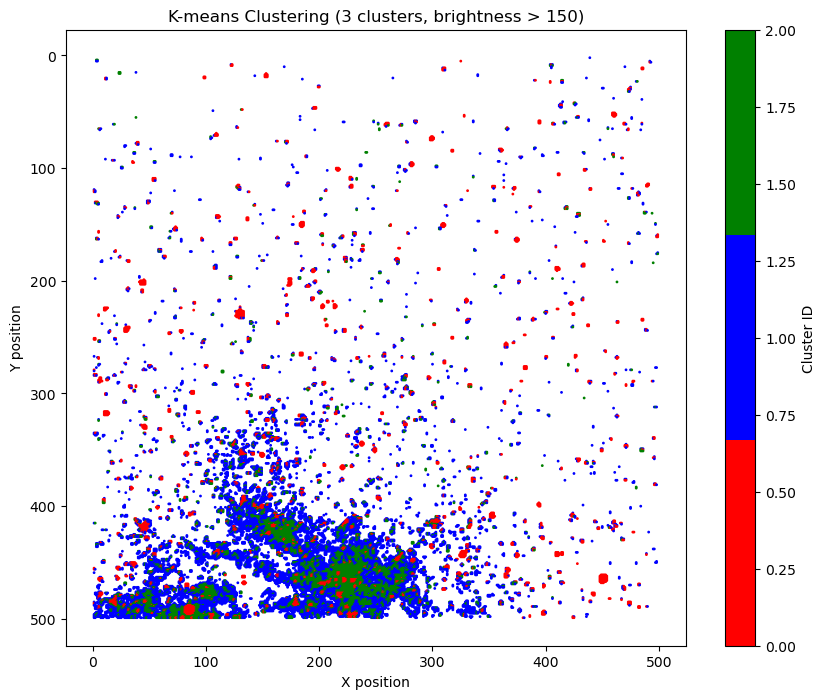

In [8]:
print(f"Intensity array shape: {intensity.shape}")      


# apply k-means clustering

n_cluster = 3  
kmeans = KMeans(n_clusters=n_cluster, n_init=10, random_state=30) # for n_cluster find 3 groups, n_init run algorithm 10 times and pick best result
labels = kmeans.fit_predict(intensity)        # fit finds the 3 cluster center, predict itterates through pixels and assigns them to nearest cluster
                                             # array with cluste id (one for each cluster)

    
print(f"Clustered {len(intensity)} pixels into {n_cluster} groups")



# Print cluster info 
print(f"\nCluster distribution:")
for i in range(n_cluster):            ## loops through each cluster
    count = np.sum(labels == i)       #creates array of True/False (True where label equals i), which then counts the Trues (how many pixels in cluster i)
    print(f"  Cluster {i}: {count} pixels ({count/len(labels)*100:.1f}%)")  ##calculates percentage in each cluster


    
print(f"\nCluster centers (RGB):")
for i, center in enumerate(kmeans.cluster_centers_):        # Loops through each cluster center
    print(f"  Cluster {i}: RGB({center[0]:.0f}, {center[1]:.0f}, {center[2]:.0f})")  
    # center[0] = Red, center[1] = Green, center[2] = Blue

    
    
my_colors = ['red', 'blue', 'green']
my_cmap = ListedColormap(my_colors)
    
# Visualize clustering
plt.figure(figsize=(10, 8))
plt.scatter(y, x, c=labels, s=1, cmap=my_cmap)
plt.title(f'K-means Clustering ({n_cluster} clusters, brightness > {bright_limit})')
plt.colorbar(label='Cluster ID')
plt.gca().invert_yaxis()
plt.xlabel('X position')
plt.ylabel('Y position')
plt.show()

### Task 6: Over-imposing our cluster to image generated in task 2. 

Total pixels: 250000
As seen in the photo, everything is just completetely overwhelming with unusable info:


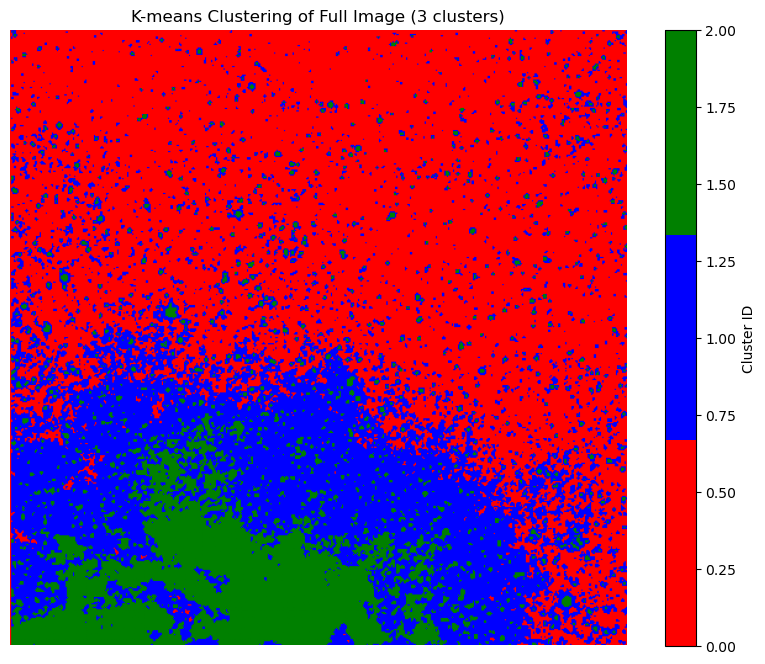

In [9]:
#Reshape ALL pixels (not just bright ones)
all_pixels = img_array.reshape(-1, 3) # Saves dimentions of picture, 360 x 360 with 3 rgb values each


print(f"Total pixels: {len(all_pixels)}")
print(f"As seen in the photo, everything is just completetely overwhelming with unusable info:")

height, width = img_array.shape[0], img_array.shape[1]

# Apply K-means to ALL pixels
kmeans_full = KMeans(n_clusters=n_cluster, n_init=10, random_state=30)
labels_full = kmeans_full.fit_predict(all_pixels)


# reshape labels back to image dimensions
clustered_image = labels_full.reshape(height, width)

plt.figure(figsize=(10, 8))
plt.imshow(clustered_image, cmap=my_cmap)
plt.title(f'K-means Clustering of Full Image ({n_cluster} clusters)')
plt.colorbar(label='Cluster ID')
plt.axis('off')
plt.show()


### Task 7: Trying different encoding. 

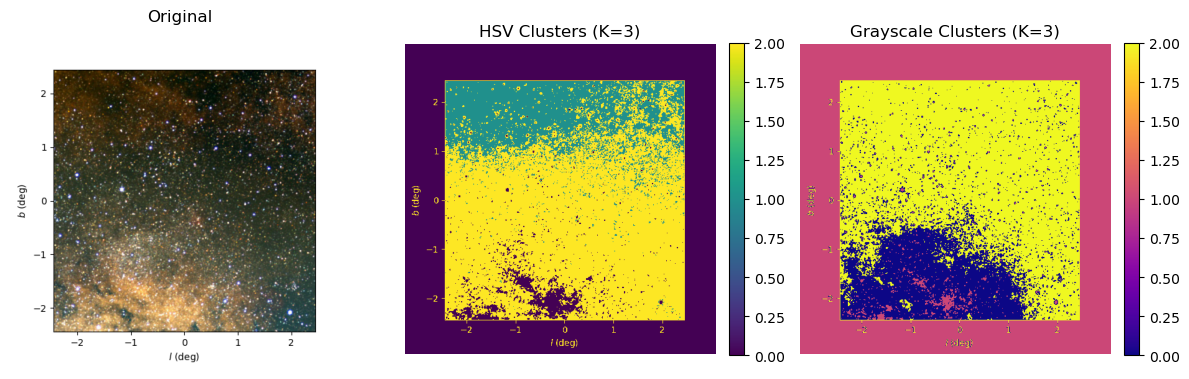

In [10]:
# This is loading the picture 
img_array = np.array(Image.open('view1.png').convert('RGB'))  # Uncommented to create img_array

# ---------------------------
# Encoding 1: HSV (Hue, Saturation, Value)
# ---------------------------
# Normalize RGB to [0,1] for hsv conversion
rgb_norm = (img_array / 255.0).astype(np.float32)
hsv = rgb_to_hsv(rgb_norm)               # shape: (H, W, 3)

# Flatten features for KMeans
features_hsv = hsv.reshape(-1, 3)

# Cluster in HSV space
k_hsv = KMeans(n_clusters=3, n_init=10, random_state=42)
labels_hsv_flat = k_hsv.fit_predict(features_hsv)
labels_hsv = labels_hsv_flat.reshape(img_array.shape[:2])

# ---------------------------
# Encoding 2: Grayscale (Brightness only)
# ---------------------------
# Luma-based grayscale (same formula you used earlier)
gray = (img_array[..., 0] * 0.299 +
        img_array[..., 1] * 0.587 +
        img_array[..., 2] * 0.114).astype(np.float32)

# Flatten brightness for KMeans (single feature per pixel)
features_gray = gray.flatten().reshape(-1, 1)

k_gray = KMeans(n_clusters=3, n_init=10, random_state=42)
labels_gray_flat = k_gray.fit_predict(features_gray)
labels_gray = labels_gray_flat.reshape(img_array.shape[:2])

# ---------------------------
# Visualize results (overlay via label maps)
# ---------------------------
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img_array)
axes[0].set_title('Original')
axes[0].axis('off')

# HSV clusters
im1 = axes[1].imshow(labels_hsv, cmap='viridis')
axes[1].set_title('HSV Clusters (K=3)')
axes[1].axis('off')
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

# Grayscale clusters
im2 = axes[2].imshow(labels_gray, cmap='plasma')
axes[2].set_title('Grayscale Clusters (K=3)')
axes[2].axis('off')
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

#### Comments 
In this task, we experimented with two different encodings for clustering the Milky Way image:

1. HSV Encoding
  * Group pixels based on hue, saturation, and brightness.
  * This approach highlights color differences, which can correspond to different star types or nebula regions.
  * The clusters tend to separate colorful regions from darker spaces, making it useful for color-based analysis.
2. Grayscale Encoding (Brightness)
  * Group pixels based on intensity only.
  * This separates bright stars from dim regions and background space.
  * It ignores color information, so clusters mainly reflect brightness patterns.

Comparison:

* HSV clustering produced more visually meaningful groupings for color-rich areas, while grayscale clustering emphasized brightness differences.
* This shows that the choice of encoding strongly influences clustering results.
* Silhouette scores (if computed) can help quantify cluster cohesion, but interpretation still depends on the chosen features.

What we learn from an unsupervised model of our galaxy:

* Unsupervised learning can reveal natural patterns (e.g., bright star clusters, color variations) without prior labels.
* However, results depend heavily on feature selection and do not guarantee physical meaning.
* These methods are best for exploratory analysis, not for definitive astrophysical conclusions.

# Topic 2: Supervised learning
## Machines versus human models, who can save the world

### Task 0: Reproducing plots to obtain data point and model prediction

To reproduce the epidemic plots and evaluate model accuracy, the following steps were implemented:
1. Data Acquisition
    - Ebola case data for Guinea, Liberia, and Sierra Leone were imported. The dataset contained daily new case counts.
2. Cumulative Case Calculation
    - The cumulative number of cases was computed from the daily new cases using *numpy.cumsum*, providing the empirical reference curve.
3. Model setup
    - The SZER-model equations were defined, incorporating compartments for susceptible, infected, and recovered individuals. The parameters $\sigma$, $\gamma$ and $N$ were set based on project guidelines.
    $$
    \frac{dS(t)}{dt}=-\beta(t)\cdot \frac{S(t)Z(t)}{N}
    $$
    
    $$
    \frac{dE(t)}{dt}=\beta(t)\cdot \frac{S(t)Z(t)}{N}-\sigma\cdot E(t)
    $$

    $$
    \frac{dZ(t)}{dt}=\sigma \cdot E(t) - \gamma Z(t)
    $$

    $$ 
    \frac{dR(t)}{dt}=\gamma Z(t)
    $$

    $$ 
    \beta (t) = \beta _0 e^{\lambda t}
    $$
    Where $\beta _0$ and $\lambda$ were unknown parameters, found by automatic optimization method to fit the model to the data for all three countries. 
4. Numerical Solver Implementation
    - A 4th orded Runge-Kutta method (RK4) was implemented to solve the system of ODEs numerically, following the structure and coding principles outlined by Hiorth (2024) 
5. Parameter Fitting
    - The model parameters $\Beta_0$ and $\lambda$ were optimized using scipy.optimize.curve_fit , minimizing the error between the model’s cumulative recovered R(t) and the actual cumulative case data.
6. Model Execution
    - The fitted parameters were used to run the RK4 solver, generating the predicted cumulative R(t) curve for each country.
7. Visualization
    - The raw cumulative data and the model prediction were plotted using matplotlib.pyplot, allowing visual comparison of model fit and empirical data.



Guinea fit parameters: 3.9307639773239296 0.09616447770893802


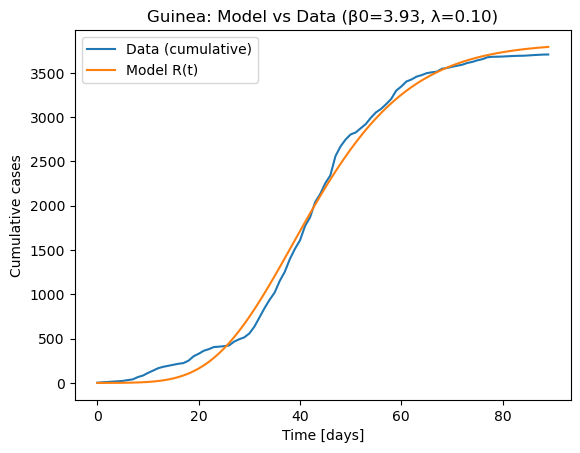

Liberia fit parameters: 25.389485693736415 0.34113193265913877


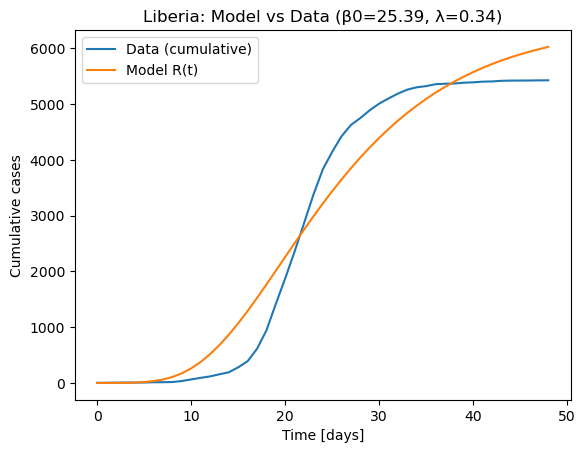

Sierra Leone fit parameters: 32.78012105969831 0.3695756975083895


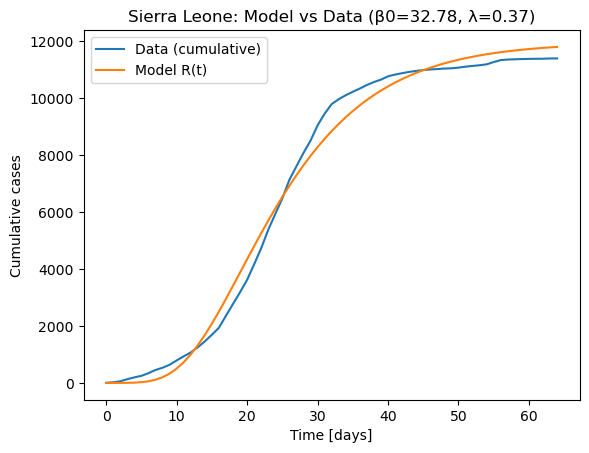

In [2]:
# File paths
FILES = {
    "Guinea": "data/ebola_cases_guinea.dat",
    "Liberia": "data/ebola_cases_liberia.dat",
    "Sierra Leone": "data/ebola_cases_sierra_leone.dat",
}
# Load data
loaded_data = EbolaDataLoader(FILES)

# Plot Guinea data
beta0_fit, lam_fit = loaded_data.fit_parameters("Guinea")
print("Guinea fit parameters:", beta0_fit, lam_fit)
loaded_data.plot_model_vs_data("Guinea", beta0_fit, lam_fit)

# Plot Liberia data
beta0_fit, lam_fit = loaded_data.fit_parameters("Liberia")
print("Liberia fit parameters:", beta0_fit, lam_fit)
loaded_data.plot_model_vs_data("Liberia", beta0_fit, lam_fit)

# Plot Sierra Leone data
beta0_fit, lam_fit = loaded_data.fit_parameters("Sierra Leone")
print("Sierra Leone fit parameters:", beta0_fit, lam_fit)
loaded_data.plot_model_vs_data("Sierra Leone", beta0_fit, lam_fit)

#### Commentary on plots

##### Guinea
The model prediction closely follow the cumulative case data. The fitted parametes $\beta _0 = 3.93$, $\lambda =0.10$ gives a curve that captures the growth and plateau behaviour of the outbreak. 

##### Liberia
With $\beta _0 = 25.39$ and $\lambda = 0.37$, the model aligns well with the overall trend, but shows a slight divergence. 

##### Sierra Leone
This last model plot fith the data very well. It follows a steep rise followed by a plateau. The close match suggest that the chosen $\beta _0 = 32.78$ and $\lambda = 0.37$ effectively captures the transmmissions dynamics.

### Task 1: Linear regression

Linear regression is the process of fitting a stright line to a set of data points. The line takes the form og a linear function with respect to its parameters: 
\begin{align}
f(x) = a+ bx
\end{align}
To determine the best fit, we need to compute the optimal values for the parameters $a$ and $b$ (the intercept and the slope). 

The technique of least-squares fit is the most commonly used measure for determining the "best" fit when noise is confined to the y-coordinate. Aksel Hiorth (2024), in his discussion on linear regression, describes this technique as "a much better approach is to square each distance and sum them". 

This method, known as the least-squares method, minimizes the total discrepancy between the actual data points and the fitted line.

#### Core Principles of the Least-Square-Fit
The least-squares fit involves finding the optimal parameters ($a$ and $b$) by minimizing the function $S$, which is the sum of the squares of the residuals:

\begin{align}
S(a,b) = \sum^n _{i=0} [y_i - f(x_i)]^2
\end{align}

1. **Residuals** 

    The term $r_i = y_i-f(x_i)$ represents the residuals or the discrepancy between the measured data point $y_i$ and the value predicted by the fitting function $f(x_i)$

2. **Minimization** 

    For linear regression, minimizing $S$ with respect to parameters *a* and *b* (i.e. setting the partial derivatives $\delta S/\delta a$ and $\delta S/\delta b$ equal to zero) yields a system of linear algebraic equations, which allows for the computation of the optimal slope and intercept. 

3. **Assumptions**

    The underlying assumption in the simplest least-squares equation is that each data point provides equally precise information about the process. If some points are affected more by measurement errors (noise), the formula can be extended using a weight factor $\omega _i$ to give those points less influence:
\begin{align}
S(a,b) = \sum^{N-1} _{i=0} \omega _i [y_i - f(x_i)]^2
\end{align}

In the context of fitting Ebola case counts (*y*) against time (*x*) with a straight line, the goal is to find the *a* and *b* parameters that minimize the total squared vertical distances between the historical case data and the line $f(x)=a+bx$.

Guinea Linear Regression Fit: slope=-482.16, intercept=54.96


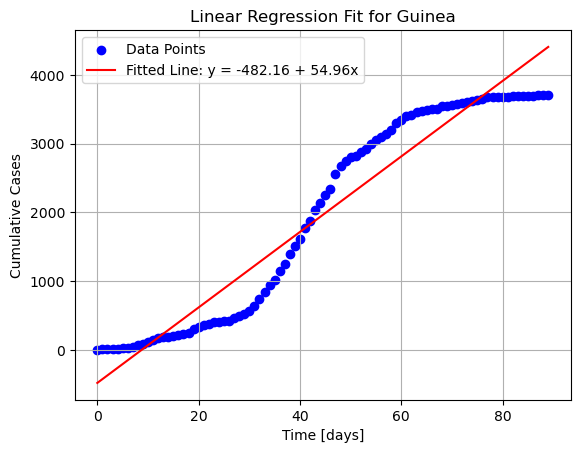

Liberia Linear Regression Fit: slope=-870.49, intercept=157.73


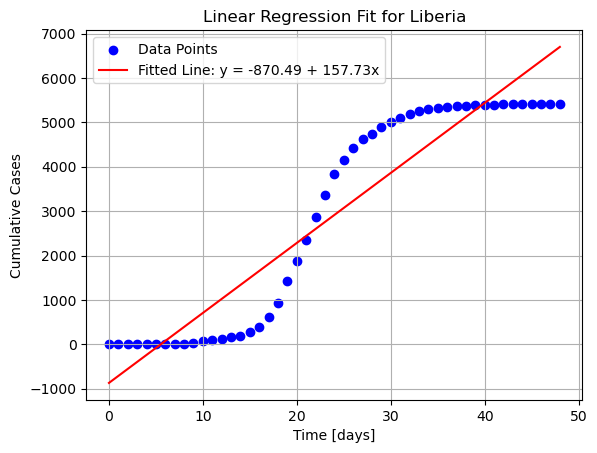

Sierra Leone Linear Regression Fit: slope=-51.28, intercept=223.20


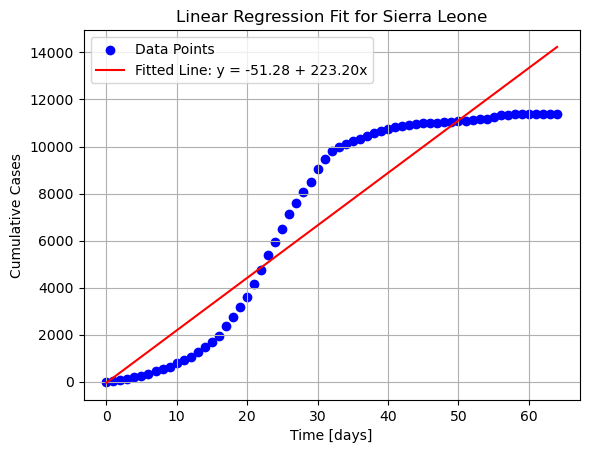

In [12]:
# Guninea

days, new_cases, cum_cases = loaded_data.get_data("Guinea")

# Create linear regression model
linReg_Guinea = LinearRegressionFit(days, cum_cases, country="Guinea")

# Fit model
a, b = linReg_Guinea.fit()
print(f"Guinea Linear Regression Fit: slope={a:.2f}, intercept={b:.2f}")

# Plot results
linReg_Guinea.plot()

# Liberia   
days, new_cases, cum_cases = loaded_data.get_data("Liberia")

# Create linear regression model
linReg_Liberia = LinearRegressionFit(days, cum_cases, country="Liberia")

# Fit model
a, b = linReg_Liberia.fit()
print(f"Liberia Linear Regression Fit: slope={a:.2f}, intercept={b:.2f}")

# Plot results
linReg_Liberia.plot()

# Sierra Leone  
days, new_cases, cum_cases = loaded_data.get_data("Sierra Leone")

# Create linear regression model
linReg_SierraLeone = LinearRegressionFit(days, cum_cases, country="Sierra Leone")

# Fit model
a, b = linReg_SierraLeone.fit()
print(f"Sierra Leone Linear Regression Fit: slope={a:.2f}, intercept={b:.2f}")

# Plot results
linReg_SierraLeone.plot()

#### Commentary on plots
While the fitted linear model captures the general upward trend in epidemic, the scatter of data points shows nonlinearity in the epidemic curve, specially in the early and late phases. This highlights the limitation of a linear regression with a simple line. 

Among the three countries, Sierra Leone exhibits the steepest slope, indicating the fastest growth in cumulative cases. Liberia follows, with Guinea showing the slowest increase. These differences may reflect variations in outbreak timing, reporting, or intervention measures.

### Task 2: Improving the fitting function
Instead of using a stright line fitting regression, we can improve it by fitting a polynomial. This involves systematically using the least-squares method to determine the coefficients of a polynomial of degree $m>1$. This process converts the curve-fitting challange into a problem of solving a system of linear algebric equations. 

1. **Defining the Model and the Objective**

    The fitting function is a polynomial of degree $m$ (where $m$ is the degree, and $m<n$ is the number of data points)

\begin{equation}
f_m(x) = a_0 f_0(x)+ a_1f_1(x)+...+a_m f_m(x) = \sum^m _{j=0}a_jf_j(x)
\end{equation}

- 
    - For a polynomial fit, the basis functions $f_j(x)$ are powers of $x$: $f_0(x) = 1, f_1(x)=x, f_2(x)=x^2, ...$
    - The parameters to be determined are the coefficients $a_0, a_1, ..., a_m$

    The best fit is achieved by minimizing the sum of the squares of the residuals, $S$, with respect to each parameter $a_k$:
\begin{equation}
S(a_0,a_1,...,a_m)=\sum^n _{i=0} [y_i - f(x_i)]^2
\end{equation}
    The optimal values of the parameters are found by solving the set of equations: $\frac{\delta S}{\delta a_k}$ for $k=0,1,...,m$.

2. Solving the Normal Equations

    Since the fitting function is linear combination of the unknown coefficients ($a_j$), the minimization conditions ($\delta S/ \delta a_k = 0 $) results in a system of linear algebraic equatiions

\begin{equation}
Aa=B
\end{equation}
Where the system is generated based on the input data point ($x_i, y_i$) and the desired polynomial order $m$.
The component of the coefficient matrix **A** and the constant vector **b** are determined by summations over the data points:
\begin{equation}   
A_{kj}=\sum^n _{i=0} f_j(x_i)f_k(x_i)  \text{and}  b_k = \sum ^n _{i=0} f_k(x_i)y_i
\end{equation}

For a polynomial fit, this involves calculating sums of $x_i$ up to the 2m power (e.g., $\sum x_i ^{2m}$).

Once we obtain the matrix **A** and vector **b**, the unknown coefficients $a = [a_0, a_1, ..., a_m]^T$ are determined by solving the linear system $Aa=b$, by using Gauss-Jordan elimination. It's a *direct* method that transforms the original equations into equivalent equations that are easier to solve, finding the solution in a finite number of steps (Hiorth,2024, p.71-75). While Gauss elimination works for well-behaved matrices, it can fail or produce highly inaccurate results if the pivot elements are poorly chosen. Pivoting is essential to maintain numerical stability and robustness.

This combination of Gauss elimination with scaled row pivotiung will give us robust solution to the linear system that arise from polynomial curve fitting. 


Best polynomial degree for Guinea: m=18 with sigma=26.63


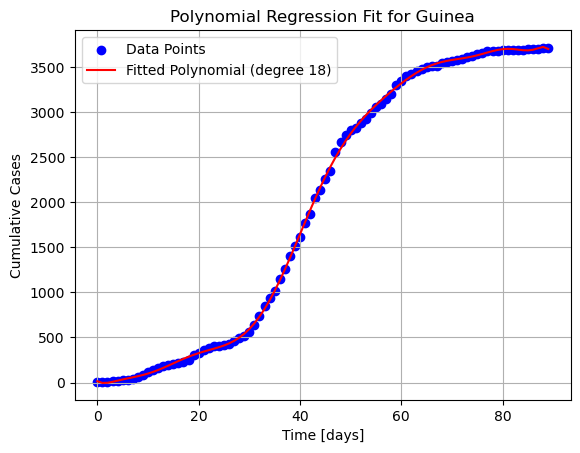

Best polynomial degree for Guinea: m=19 with sigma=28.90


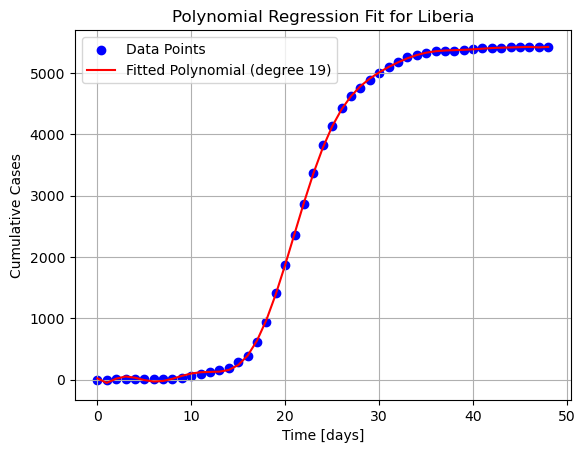

Best polynomial degree for Guinea: m=16 with sigma=38.64


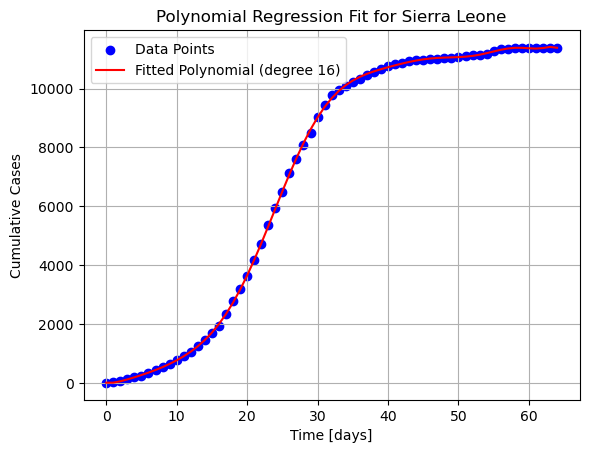

In [13]:
# Guinea - Polynomial Regression Fit
days, new_cases, cum_cases = loaded_data.get_data("Guinea")

# Loop to test different polynomial degrees
best_m = None 
best_sigma = float('inf')
best_coeffs = None

for m in range(1, 21):
    polyreg = PolynomialRegressionFit(days, cum_cases, country="Guinea")
    coeffs = polyreg.polyFit(m=m)
    sigma = polyreg.fit_quality()
    
    if sigma < best_sigma:
        best_sigma = sigma
        best_m = m
        best_coeffs = coeffs

print(f"Best polynomial degree for Guinea: m={best_m} with sigma={best_sigma:.2f}")

# Plot best fit
polyReg = PolynomialRegressionFit(days, cum_cases, country="Guinea")
polyReg.polyFit(m=best_m)
polyReg.plot_fit()

# Liberia - Polynomial Regression Fit
days, new_cases, cum_cases = loaded_data.get_data("Liberia")

# Loop to test different polynomial degrees
best_m = None 
best_sigma = float('inf')
best_coeffs = None

for m in range(1, 21):
    polyreg = PolynomialRegressionFit(days, cum_cases, country="Liberia")
    coeffs = polyreg.polyFit(m=m)
    sigma = polyreg.fit_quality()
    
    if sigma < best_sigma:
        best_sigma = sigma
        best_m = m
        best_coeffs = coeffs

print(f"Best polynomial degree for Guinea: m={best_m} with sigma={best_sigma:.2f}")

# Plot best fit
polyReg = PolynomialRegressionFit(days, cum_cases, country="Liberia")
polyReg.polyFit(m=best_m)
polyReg.plot_fit()

# Sierra Leone - Polynomial Regression Fit
days, new_cases, cum_cases = loaded_data.get_data("Sierra Leone")

# Loop to test different polynomial degrees
best_m = None 
best_sigma = float('inf')
best_coeffs = None

for m in range(1, 21):
    polyreg = PolynomialRegressionFit(days, cum_cases, country="Sierra Leone")
    coeffs = polyreg.polyFit(m=m)
    sigma = polyreg.fit_quality()
    
    if sigma < best_sigma:
        best_sigma = sigma
        best_m = m
        best_coeffs = coeffs

print(f"Best polynomial degree for Guinea: m={best_m} with sigma={best_sigma:.2f}")

# Plot best fit
polyReg = PolynomialRegressionFit(days, cum_cases, country="Sierra Leone")
polyReg.polyFit(m=best_m)
polyReg.plot_fit()



### Task 3: Neural Network and predicting the epidemic evolution

A neural network is a machine learning model designed to mimic the complex function of the human brain, consisting of interconnected nodes or neurons that process data and learn pattern (GeeksforGeeks b, 2025). Training a NN-network to predict epidemic evolution falls under the category of supervised learning, specifically a regression task, as the output (population counts, cases) is a continuous variable over time. 

#### Epidemic Data Preparation
As described in Project2, the prediction of epidemic evolution typically involves analyzing comparment models (like the SEZR model) describing the change in populations (S, E, Z, R) over time. To use an NN, this data must first be converted into a tabular or flat file format, where one column is tha target variable and others are predictors (Statistics Ninja, 2023). 

#### The Standard Split and the Chronological Assumptions
In standard supervised learning, the dataset is typically split into training data (e.g., 80%) and testing data (e.g., 20%). The model learns patterns from the training set and is evaluated on the test set, which represents unseen data (GeeksforGeeks d, 2025). When modeling an evolving process, like an epidemic predicted by differential equations, the most important assumption for accurate prediction is that the model must use past information to predict future. 

#### Training with the Neural Networsk using ***MLPRegressor***
The neural network is implemented using *MLPRegressor* from *scikit‑learn*. In the code, hidden layers such as (128, 64) are specified to give the model enough capacity to capture nonlinear epidemic behavior. The predictors are scaled with *StandardScaler*, and the model is trained on the training set before being evaluated on the test set. The RMS error is then calculated to measure prediction accuracy, and plots are generated to compare actual vs predicted epidemic curves.

Guinea fit parameters: 3.9307639773239296 0.09616447770893802


c:\Users\marzs\anaconda3\envs\MOD300\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\marzs\anaconda3\envs\MOD300\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\marzs\anaconda3\envs\MOD300\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\marzs\anaconda3\envs\MOD300\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\marzs\anaco

Guinea Best fit alpha: 0.001
Guinea NN RMS Error: 129358.904


c:\Users\marzs\anaconda3\envs\MOD300\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


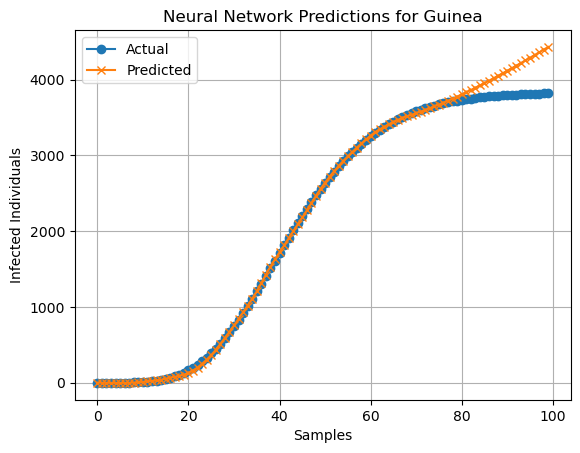

Liberia fit parameters: 25.389485693736415 0.34113193265913877


c:\Users\marzs\anaconda3\envs\MOD300\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\marzs\anaconda3\envs\MOD300\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\marzs\anaconda3\envs\MOD300\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\marzs\anaconda3\envs\MOD300\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\marzs\anaco

Liberia Best fit alpha: 0.0001
Liberia NN RMS Error: 277127.553


c:\Users\marzs\anaconda3\envs\MOD300\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


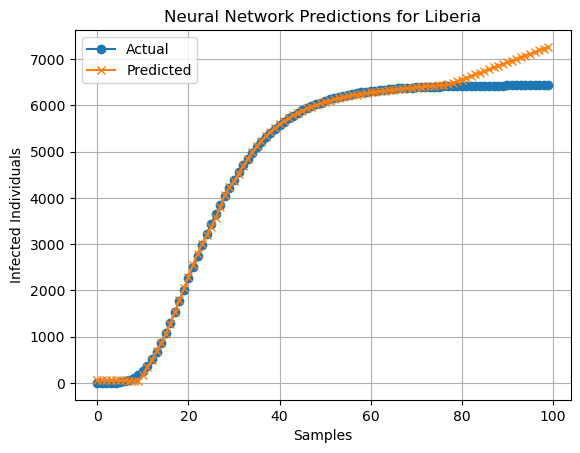

Sierra Leone fit parameters: 32.78012105969831 0.3695756975083895


c:\Users\marzs\anaconda3\envs\MOD300\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\marzs\anaconda3\envs\MOD300\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\marzs\anaconda3\envs\MOD300\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\marzs\anaconda3\envs\MOD300\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\marzs\anaco

Sierra Leone Best fit alpha: 1e-05
Sierra Leone NN RMS Error: 1038898.749


c:\Users\marzs\anaconda3\envs\MOD300\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


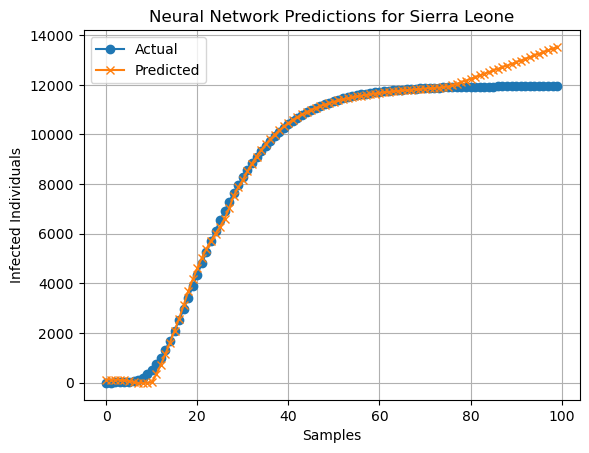

In [3]:
counties = ["Guinea", "Liberia", "Sierra Leone"]

for country in counties:
    # Load country data and fit parameters
    days, new_cases, cum_cases = loaded_data.get_data(country)
    beta0_fit, lam_fit = loaded_data.fit_parameters(country)
    print(f"{country} fit parameters:", beta0_fit, lam_fit)

    # Simulate SEZR model for each with fitted parameters
    days_extended = np.arange(0, 100)  # Simulate 100 days
    t_model, S, E, Z, R = loaded_data.simulate_SEZR_NN(beta0_fit, lam_fit, t_days=days_extended, Z0=1.0)

    # Normalize compartment values
    S_norm = S / loaded_data.N
    E_norm = E / loaded_data.N
    Z_norm = Z / loaded_data.N

    # predict cumulative cases
    y = R

    # predictors with normalized values
    X = np.column_stack((t_model, S_norm, E_norm, Z_norm))

    # Train neural network model
    nn_model = NNEpidemicPrediction(X, y, country=country)

    # Find best alpha
    nn_model.find_best_alpha()

    # Train model with best alpha
    nn_model.trainNN(hidden=(128, 64), max_iter=2000, alpha=nn_model.best_alpha)

    # Plot results
    nn_model.plot_predictions()

#### Summary 
The neural network predictions for Guinea, Liberia, and Sierra Leone shows a reasonably good fit to the SEZR-generated epidemic curves. During this initial phase, the model captures the nonlinear growth and early saturation dynamics of cumulative removals. However, we can see that the predictions begin to diverge upward, overshooting the actual trajectory in all 3 cases. 

The late-stage overshoot may be caused due to the 80/20 chronological split. Since the NN only trains on the first 80% of the epidemic curve, and doesn't fully learn the plateau phase. When predicting the last 20%, it extrapolates upward, leading to deviation. Adjusting the split ratio, using daily removals as targets, can help the NN capture the late-stage dynamics more accurately.

### Task 4: LSTM network and prediction the epidemic evolution

In [17]:
from tensorflow.keras.layers import LSTM

# Reshape for LSTM
X_lstm = X.reshape((X.shape[0], X.shape[1], 1))

model_lstm = Sequential([
    LSTM(50, input_shape=(look_back, 1)),
    Dense(1)
])
model_lstm.compile(optimizer='adam', loss='mse')
model_lstm.fit(X_lstm[:split], y_train, epochs=50, batch_size=16, verbose=0)

# Predicting the Epidemic Evolution 
pred_train_lstm = model_lstm.predict(X_lstm[:split])
pred_test_lstm = model_lstm.predict(X_lstm[split:])

# Invert scaling
pred_train_lstm_inv = scaler.inverse_transform(pred_train_lstm)
pred_test_lstm_inv = scaler.inverse_transform(pred_test_lstm)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(series, label="Actual")
plt.plot(range(look_back, look_back+len(pred_train_lstm_inv)), pred_train_lstm_inv, label="Train Pred")
plt.plot(range(look_back+len(pred_train_lstm_inv), look_back+len(pred_train_lstm_inv)+len(pred_test_lstm_inv)), pred_test_lstm_inv, label="Test Pred")
plt.title(f"LSTM Prediction for {country}")
plt.legend()
plt.show()



NameError: name 'look_back' is not defined

### Task 5: Discussion on the results.
The question we being ask is if we can ignore modeling and let machine learning make predictions, and it's a no. Neural networks are strong pattern recognizers, but they may be risky. Mechanistic model like SEZR provide essential insight into the biological process, that MLPRegressor cannot capture on its own. Ignoring the mechanistic modeling means losing the ability to understand why epidemic grows or slows down. 

A good prediction is one that not only fits the early growth phase, but also correctly predicts the plateau and saturation of the epidemic.In our results for task 3, the NN matched the growth wand early plateau well, but we are getting overshoot in the late stage because the training set did not include enough of the saturation phase. A good prediction therefore requires careful assumption( e.g., daily removals, susceptible populatuin left), and a training split that exposes the model to the full epidemics dynamics. 

Neaural networks are useful tools for approximating complex epidemic curves, but the cannot fully replace mechanistic models. The overshoot we observed highlights the danger of chronological splits that trains only on growth and test on saturation. The most reliable approach is combining mechanistic features with machine learning so the NN is guided by epidemiological constraints. This way, the predictions remain accurate across both the growth and plateaus phases, avoiding the overshoots deviations.

# Summary and Reflection

This project was completed by Marzena Katarzyna Switon, Patrick Roarson Teigen and Daniel Ulstad Kaarvaag. The tasks were divided so that each of us contributed equally while also reviewing and checking each other’s work.

#### **Marzena Switon**
**Exercise completed:** Topic 2, Exercise 0-3, 5

**What I learned:**
- From Task 0, I learned how to reproduce epidemic plots by combining real Ebola case data with a mechanistic compartment model (SEZR).
- From Task 1, I learned the fundamentals of linear regression and how it applies to epidemic data. I understood how the least‑squares method minimizes residuals to find the best slope and intercept for a straight line. By applying this to Ebola case counts, I saw that while linear regression can capture the overall upward trend, it fails to represent the nonlinear dynamics of an epidemic, especially in the early exponential growth and late plateau phases. This highlighted the limitations of simple statistical models compared to mechanistic approaches.
- In Task 2, I learned how polynomial regression can improve curve fitting compared to a simple straight line. By extending the least‑squares method to polynomials of degree $𝑚>1$, the fitting function can capture nonlinear trends in the data, which is especially important for epidemic curves that show both rapid growth and eventual plateau.
- From Topic 2, Task 3, I learned how a neural network can be applied to epidemic modeling, and whats its strengths and limitations. This task taught me that neural networks can approximate epidemic dynamics, but they are not perfect substitutes for mechanistic models. They need careful data preparation, thoughtful splitting strategies, and sometimes alternative targets to capture the full epidemic evolution.

**Personal insight:**

--------------

#### **Patrick Roarson Teigen**
**Exercise completed:** Topic 1, Exercise 1 - 6

**What I learned:**
 - Throughout this assignment regarding analyzing images with unsupervised learning, espacially images of the Milky Way galaxy, I have learned about image processing and gained insight into how images are represented as numerical arrays (pixels with RGB values) and how to manipulate them programmatically.

 - I have discovered that unsupervised learning can find natural patterns in data without being told what to look for (all though i like instructions:). The algorithm automatically groups similar colored pixels, and I understood that there is no "correct" way of setting up the algorithm. It can vary on what you want to analyze, and therefor how you interpret the results. Even with a clear idea of what parameters should be (f.eks, the brightness threshold).

**Personal insight:**

Initially I struggled with matching code to tasks and understanding what the guidelines for what some of the tasks asked for. However, through experimentation I realized that data manipulation is as much about asking the right questions as it is about technical implementation. In other terms trial and error in the sense that you need to do what you think, and what suits your understanding the best.

----------------------


#### **Daniel Ulstad Kaarvaag**
**Exercise completed:** Topic 1 , Exersice 7. Topic 2 , Exersice 4

**What I learned:**
 - This project taught me how to apply both unsupervised and supervised machine learning methods to real world problems. i leard how to process astronomical images by converting them into numerical arrays. I explored differnt encodings (Color based and brightness based grayscale). Using K-means , i discovered that unsuperviesd models can reveal patterns like bright star regions or color variations.from the main insight from topic 1: learning is great for exploratory analyssis , but it does not guarantee physical meaning knowledge

- Linear and ploynomial regression: simple but its limited for capturing epidemic curves. Neural network (dense) better for non-linear patterns but ignores memory for the sequens. Lstm captures temporal dependencies and produced the most realstic predictions.

**Personal insight:**

This project involed many trails , errors and debugging moments. At times , it was frustrating when things didnt work as expected, espeically with new concepts like clustering encodings and lstm models. however , these challenges helped me learn a lot about problem solving and how machine learning methods work in practice. despite the difficulties, i'm happy with the learning experience and the knowledge i gained from this project and course. 

----------------------

# A statement on the eventual usage of AI:
For this project we have used AI to help us decode the questions (which reflected on as hard to interpret). As for other task AI has been used to brainstom options when we got stuck on a task. 

# References:

GeeksforGeeks a. (2025, July 23). What is grayscale image? Retrieved from https://www.geeksforgeeks.org/electronics-engineering/what-is-grayscale-image/

GeeksforGeeks b. (2025, October 7). What is a Neural Network? Retrieved from https://www.geeksforgeeks.org/machine-learning/neural-networks-a-beginners-guide/

GeeksforGeeks c. (2025, November 10). K means clustering – Introduction. Retrieved from https://www.geeksforgeeks.org/machine-learning/k-means-clustering-introduction/

GeeksforGeeks d. (2025, September 12). Supervised Macine Learning. Retrieved from https://www.geeksforgeeks.org/machine-learning/supervised-machine-learning/

Hiorth, A. (2025, September 5). Modeling and computational engineering. University of Stavanger.

Kiusalaas, J. (2013). Numerical methods in engineering with Python 3. New York, NY: Cambridge University Press.

Leung, H. (2025, June 24). Welcome to mw-plot’s documentation! Retrieved from https://milkyway-plot.readthedocs.io/en/stable/#welcome-to-mw-plot-s-documentation

Project 2. (2025). Modeling a zombie outbreak – SZ model. Course material/assignment document.

Riccardi, E. (2025). Sketchbook for galaxy plotter.

scikit learn- https://scikit-learn.org/stable/modules/neural_networks_supervised.html.

Statistics Ninja. (2023, October 7). 17 Neural Networks in Supervised Learning.  Retrieved from https://www.youtube.com/watch?v=hZZM5SwhAXM&list=TLGGqUZYJPIFyZswMjEyMjAyNQ